# Experiment 4.4.3 — Heterogeneous Stage-2 membrane timescales

Analysis-only notebook. It recomputes mean/SD/count from finalized `runs.csv`, then compares `single250`, `single500`, `tau250_500`, and `tau125_250_500`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'AGENTS.md').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find writingRing repository root')

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_4_4_3_multitau_memory' / 'stage2_multitau_dense_v1'
EXPECTED_SEEDS = (11, 23, 37, 53, 71)
EXPECTED_PROFILES = ('single250','single500','tau250_500','tau125_250_500')
required = ('runs.csv','summary.csv','paired_effects.csv','paired_effects_summary.csv','manifest.json')
missing = [name for name in required if not (ARTIFACT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing finalized Exp4.4.3 artifacts: {missing}')
runs = pd.read_csv(ARTIFACT_DIR / 'runs.csv')
finalized_summary = pd.read_csv(ARTIFACT_DIR / 'summary.csv')
effects = pd.read_csv(ARTIFACT_DIR / 'paired_effects.csv')
finalized_effects_summary = pd.read_csv(ARTIFACT_DIR / 'paired_effects_summary.csv')
manifest = json.loads((ARTIFACT_DIR / 'manifest.json').read_text())
test = runs[runs['split'] == 'test'].copy()
assert set(test['seed']) == set(EXPECTED_SEEDS)
assert set(test['profile']) == set(EXPECTED_PROFILES)
assert len(test) == len(EXPECTED_SEEDS) * len(EXPECTED_PROFILES)
metric_cols = ['output_whole_count_ba','hidden_whole_count_linear_ba','uend_linear_ba','uend_minus_hidden_count_ba','uend_minus_output_count_ba','state_events_per_neuron_second','output_events_per_neuron_second','state_tail_event_fraction','output_tail_event_fraction']
summary = test.groupby(['profile','is_heterogeneous','tau_profile_ms','group_widths'])[metric_cols].agg(['mean','std','count']).reset_index()
summary.columns = ['_'.join(str(part) for part in col if str(part)) if isinstance(col, tuple) else str(col) for col in summary.columns]
effects_summary = effects.groupby(['effect','profile','baseline','readout'])['delta_ba'].agg(['mean','std','count']).reset_index()
manifest


{'baseline_single_taus': [250, 500],
 'experiment_id': 'experiment_4_4_3_multitau_memory',
 'files': {'paired_effects': 'paired_effects.csv',
  'paired_effects_summary': 'paired_effects_summary.csv',
  'runs': 'runs.csv',
  'summary': 'summary.csv'},
 'fixed': {'local_condition': 'shift34',
  'output_tau_mem_ms': 250.0,
  'stage2_topology': 'dense',
  'stage2_width': 128,
  'threshold': 0.5,
  'training_objective': 'valid normalized output WholeCount CE',
  'variant': 'multi_ho'},
 'multitau_profiles': {'tau125_250_500': [125, 250, 500],
  'tau250_500': [250, 500]},
 'new_training_runs': 10,
 'parameter_note': 'Only fixed per-neuron beta/tau assignment changes; trainable parameter count is unchanged.',
 'primary_comparison': 'each heterogeneous profile versus single250 paired by seed',
 'protocol_version': 'stage2_multitau_dense_v1',
 'question': 'Can heterogeneous Stage-2 membrane timescales improve the Dense-RSNN gesture-level state beyond the best homogeneous single-tau architecture

## Notebook aggregation
The following table is recomputed from seed-level `runs.csv`; finalizer summaries remain as reference artifacts. Heterogeneous profiles do not change trainable parameter count.


In [2]:
cols = ['profile','is_heterogeneous','tau_profile_ms','group_widths','uend_linear_ba_mean','uend_linear_ba_std','hidden_whole_count_linear_ba_mean','hidden_whole_count_linear_ba_std','output_whole_count_ba_mean','output_whole_count_ba_std','uend_minus_hidden_count_ba_mean','uend_minus_output_count_ba_mean']
display(summary[cols].sort_values('profile').reset_index(drop=True))


,profile,is_heterogeneous,tau_profile_ms,group_widths,uend_linear_ba_mean,uend_linear_ba_std,hidden_whole_count_linear_ba_mean,hidden_whole_count_linear_ba_std,output_whole_count_ba_mean,output_whole_count_ba_std,uend_minus_hidden_count_ba_mean,uend_minus_output_count_ba_mean
0,single250,False,250,128,0.544495,0.014334,0.502100,0.024833,0.497990,0.047480,0.042394,0.046505
1,single500,False,500,128,0.528518,0.042688,0.483900,0.024447,0.466639,0.039182,0.044618,0.061878
2,tau125_250_500,True,125/250/500,43/43/42,0.517723,0.027872,0.517293,0.038422,0.483150,0.047542,0.000431,0.034573
3,tau250_500,True,250/500,64/64,0.508590,0.090762,0.480286,0.056492,0.474744,0.065953,0.028304,0.033846


## Endpoint memory quality
Primary question: does either heterogeneous profile exceed the homogeneous `single250` Uend memory reference?


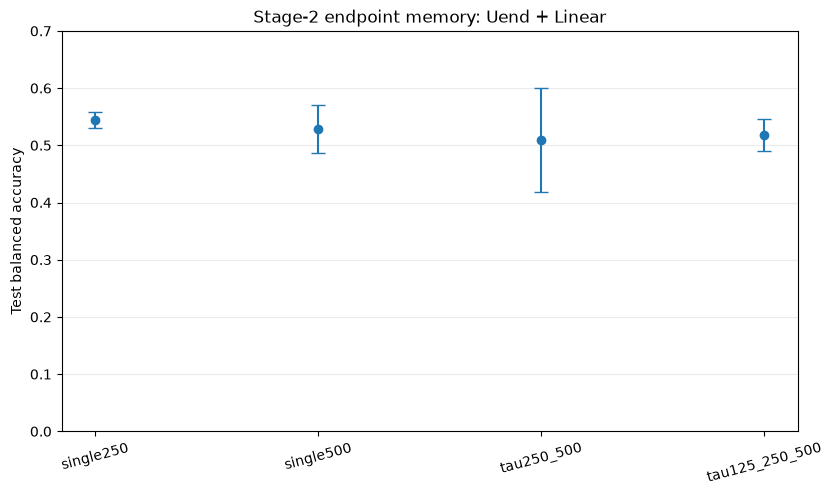

In [3]:
order = list(EXPECTED_PROFILES)
frame = summary.set_index('profile').loc[order]
profile_x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5,5.2))
ax.errorbar(profile_x, frame['uend_linear_ba_mean'], yerr=frame['uend_linear_ba_std'], marker='o', linestyle='none', capsize=5)
ax.set_xticks(profile_x, order, rotation=15)
ax.set_ylabel('Test balanced accuracy')
ax.set_ylim(0,0.7)
ax.set_title('Stage-2 endpoint memory: Uend + Linear')
ax.grid(axis='y', alpha=0.25)
plt.show()


## Paired gain versus single250
This is the primary architecture comparison because `single250` was the best homogeneous Dense-RSNN endpoint-memory condition in Exp4.4.1.


,effect,profile,baseline,readout,mean,std,count
0,tau125_250_500_minus_single250,tau125_250_500,single250,uend_linear,-0.026772,0.034282,5
1,tau250_500_minus_single250,tau250_500,single250,uend_linear,-0.035905,0.098378,5


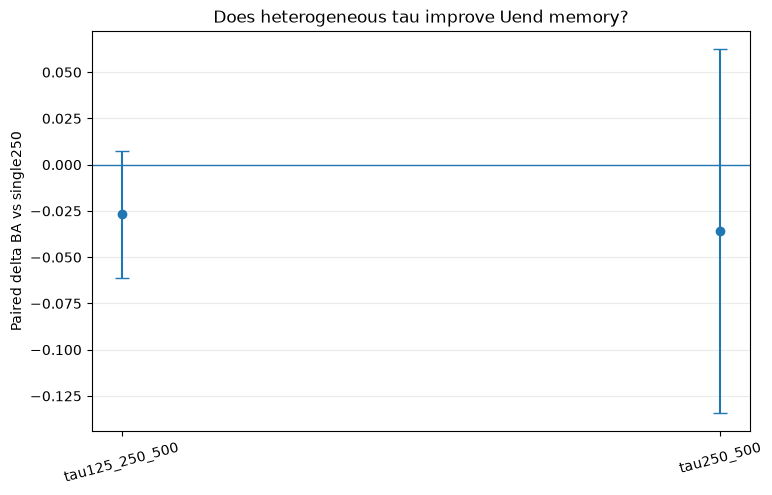

In [4]:
primary = effects_summary[(effects_summary['baseline'] == 'single250') & (effects_summary['readout'] == 'uend_linear')].copy().sort_values('profile')
display(primary.reset_index(drop=True))
primary_x = np.arange(len(primary))
fig, ax = plt.subplots(figsize=(8.5,5.2))
ax.errorbar(primary_x, primary['mean'], yerr=primary['std'], marker='o', linestyle='none', capsize=5)
ax.set_xticks(primary_x, primary['profile'], rotation=15)
ax.axhline(0, linewidth=1)
ax.set_ylabel('Paired delta BA vs single250')
ax.set_title('Does heterogeneous tau improve Uend memory?')
ax.grid(axis='y', alpha=0.25)
plt.show()


## Full readout matrix
A profile can improve Uend memory without improving spike-accessible count readouts. Keep all three levels visible.


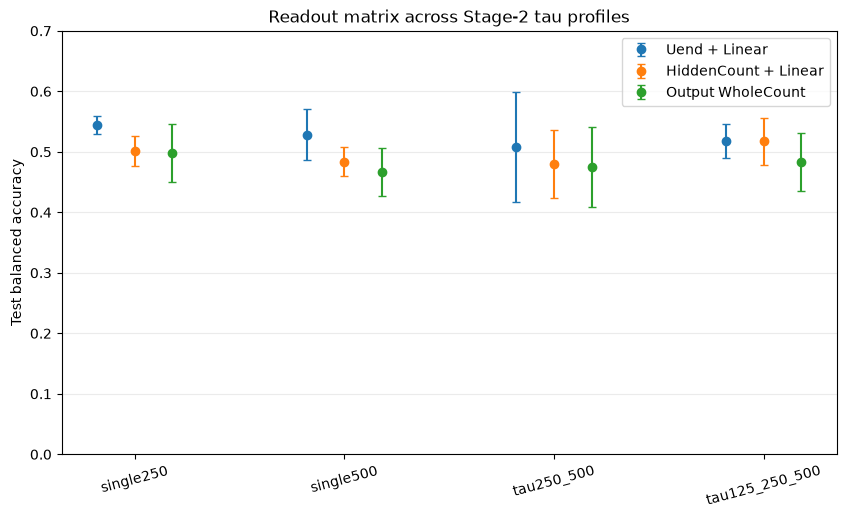

In [5]:
readouts = {'Uend + Linear':('uend_linear_ba_mean','uend_linear_ba_std'),'HiddenCount + Linear':('hidden_whole_count_linear_ba_mean','hidden_whole_count_linear_ba_std'),'Output WholeCount':('output_whole_count_ba_mean','output_whole_count_ba_std')}
fig, ax = plt.subplots(figsize=(10,5.5))
offsets = np.linspace(-0.18,0.18,len(readouts))
for offset, (label, (mean_col, std_col)) in zip(offsets, readouts.items()):
    ax.errorbar(profile_x + offset, frame[mean_col], yerr=frame[std_col], marker='o', linestyle='none', capsize=3, label=label)
ax.set_xticks(profile_x, order, rotation=15)
ax.set_ylabel('Test balanced accuracy')
ax.set_ylim(0,0.7)
ax.set_title('Readout matrix across Stage-2 tau profiles')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.show()


## State-to-spike information gap
A larger positive Uend-to-count gap means useful endpoint information is not yet efficiently expressed by spikes.


,profile,uend_minus_hidden_count_ba_mean,uend_minus_output_count_ba_mean
0,single250,0.042394,0.046505
1,single500,0.044618,0.061878
2,tau250_500,0.028304,0.033846
3,tau125_250_500,0.000431,0.034573


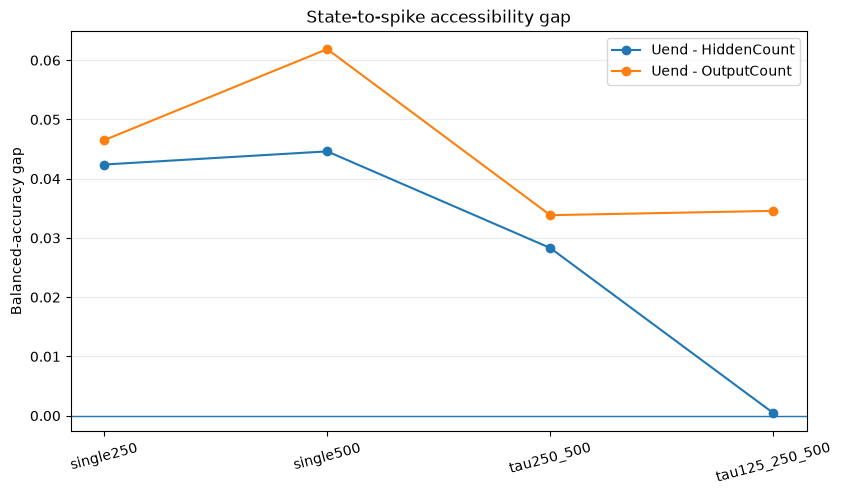

In [6]:
gap_cols = ['profile','uend_minus_hidden_count_ba_mean','uend_minus_output_count_ba_mean']
display(frame.reset_index()[gap_cols])
fig, ax = plt.subplots(figsize=(9.5,5.2))
ax.plot(profile_x, frame['uend_minus_hidden_count_ba_mean'], marker='o', label='Uend - HiddenCount')
ax.plot(profile_x, frame['uend_minus_output_count_ba_mean'], marker='o', label='Uend - OutputCount')
ax.axhline(0, linewidth=1)
ax.set_xticks(profile_x, order, rotation=15)
ax.set_ylabel('Balanced-accuracy gap')
ax.set_title('State-to-spike accessibility gap')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.show()


## Firing and tail diagnostics
Use these to distinguish a useful multi-timescale state from a configuration that merely increases persistent activity.


,profile,state_events_per_neuron_second_mean,output_events_per_neuron_second_mean,state_tail_event_fraction_mean,output_tail_event_fraction_mean
0,single250,37.318184,180.471386,0.232276,0.224421
1,single500,31.241393,143.436717,0.271882,0.239233
2,tau250_500,32.490678,148.750894,0.419505,0.404276
3,tau125_250_500,35.089939,177.164968,0.282696,0.271818


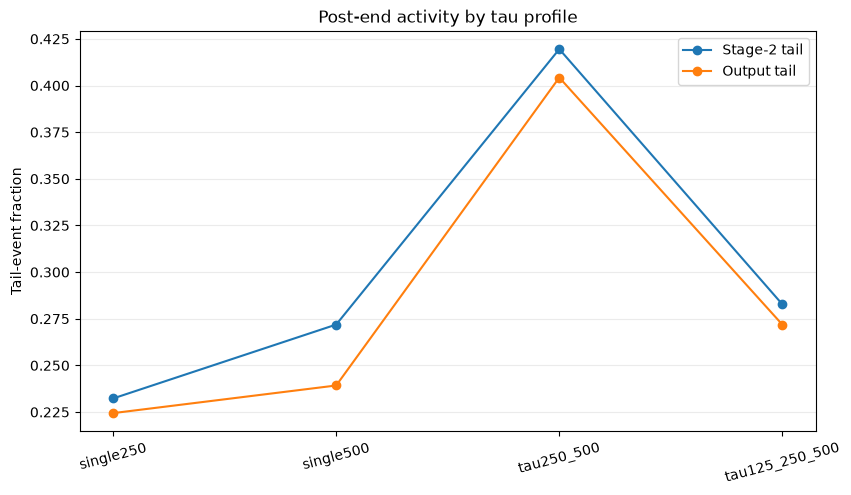

In [7]:
diag_cols = ['profile','state_events_per_neuron_second_mean','output_events_per_neuron_second_mean','state_tail_event_fraction_mean','output_tail_event_fraction_mean']
display(frame.reset_index()[diag_cols])
fig, ax = plt.subplots(figsize=(9.5,5.2))
ax.plot(profile_x, frame['state_tail_event_fraction_mean'], marker='o', label='Stage-2 tail')
ax.plot(profile_x, frame['output_tail_event_fraction_mean'], marker='o', label='Output tail')
ax.set_xticks(profile_x, order, rotation=15)
ax.set_ylabel('Tail-event fraction')
ax.set_title('Post-end activity by tau profile')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.show()


## Decision rule
Prefer a heterogeneous profile only if the paired Uend gain over `single250` is positive and seed-consistent. During this architecture phase, Output WholeCount remains secondary; a larger Uend-to-count gap is evidence for later state-to-spike expression work.
